# Project 3: Ohio Climate Study
 Tren Meckel , Kate Ngo , Faye Desarro <br>
 October 30, 2024

## **Introduction**
In early 2020, the Midwest experienced a "dual disaster" as severe spring flooding converged with the COVID-19 pandemic (American Flood Coalition, 2020). This study focuses on analyzing weather data in Ohio—specifically, gage height and discharge levels in Granville, alongside precipitation and temperature data from the National Weather Service (NWS) in Columbus, located approximately 30 minutes away. By examining these factors, we aim to understand the environmental conditions leading up to the March 20th, 2020 flood event.

In addition to the physical impact of flooding, this study explores potential correlations between flood events and an increase in COVID-19 spread in affected areas. While there are no direct reports of sewage overflow in Granville, nearby communities like Heath reported significant wastewater overflows during this period, causing backups into homes and properties (Newark Advocate, 2020). Given that COVID-19 has been detected in untreated sewage, these flood-induced wastewater events may have presented heightened transmission risks (National Library of Medicine, 2020).

Furthermore, this flood event likely compounded the challenges faced by local communities like Granville, which not only dealt with typical flood disruptions to resources and homes but also had to navigate these disruptions during a pandemic. With limited access to supplies and stores due to COVID-19, residents faced intensified resource scarcity and displacement challenges. This project thus seeks to highlight not only the source behind the flooding event, but the local communties impacted by this "dual disaster". 


### Import Statements
Include any import statements you want in the cell below.  

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

### Read in the data (three csv files) and assigns the files (gage and discharge) to Dataframes 

In [2]:
gageread = pd.read_csv("Gage.csv", header = None)
dischargeread = pd.read_csv("Discharge.csv", header = None)
nws_df = pd.read_csv('nws.csv')

gage = pd.DataFrame(gageread)
discharge = pd.DataFrame(dischargeread)

## **Tidying the Data**

In [14]:
gage.iloc[:, 0] = gage.iloc[:, 0].astype(str)
gagedf = pd.DataFrame()
gagedf[['Agency', 'Site', 'Date', 'Time', 'Timezone', 'Gage', 'Code']] = gage.iloc[:, 0].str.split(r"\s+", expand = True)
discharge.iloc[:, 0] = discharge.iloc[:, 0].astype(str)
dischargedf = pd.DataFrame()
dischargedf[['Agency', 'Site', 'Date', 'Time', 'Timezone', 'Discharge', 'Code']] = discharge.iloc[:, 0].str.split(r"\s+", expand = True)
merged = pd.merge(left = gagedf, right = dischargedf, on = ["Agency", "Site", "Timezone", "Date", "Time", "Code"])

      Agency      Site        Date   Time Timezone  Gage Code Discharge
0       USGS  03145483  2020-01-01  01:00      EST  4.23    A       145
1       USGS  03145483  2020-01-01  01:15      EST  4.22    A       144
2       USGS  03145483  2020-01-01  01:30      EST  4.21    A       143
3       USGS  03145483  2020-01-01  01:45      EST  4.21    A       143
4       USGS  03145483  2020-01-01  02:00      EST  4.20    A       141
...      ...       ...         ...    ...      ...   ...  ...       ...
28584   USGS  03145483  2020-12-31  23:45      EST  5.50    A       379
28585   USGS  03145483  2021-01-01  00:00      EST  5.48    A       374
28586   USGS  03145483  2021-01-01  00:15      EST  5.47    A       372
28587   USGS  03145483  2021-01-01  00:30      EST  5.44    A       366
28588   USGS  03145483  2021-01-01  00:45      EST  5.42    A       361

[28589 rows x 8 columns]


### Explanation

In the above code chunk, we split the orginal dataset, which only had one column and many data entries in one cell. We renamed the columns of the datasets. Both datasets we got from USGS - Gage and Discharge - contains data collected in the same time frame, at the same intervals, and from the same area. Therefore, we can safely merge the datasets on these variables: Agency (who collected the data), Site (where the data was collected - Granville), Date, Time, Timezone, and Code.

## **Merging Tidying Data with NWS cvs file**

In [4]:
def calculate_daily_averages(merged_df):
    """
    Calculate the daily averages of 'Gage' and 'Discharge' values from the merged DataFrame.
    
    Parameters:
    merged_df (pd.DataFrame): A DataFrame containing merged 'Gage' and 'Discharge' data with columns 
                              ['Agency', 'Site', 'Date', 'Time', 'Timezone', 'Gage', 'Discharge', 'Code'].

    Returns:
    pd.DataFrame: A DataFrame with the daily averages for 'Gage' and 'Discharge'.
    """
    
    # Convert 'Date' to datetime format
    merged_df['Date'] = pd.to_datetime(merged_df['Date'], format='%Y-%m-%d')
    
    # Convert 'Gage' and 'Discharge' to numeric, coercing errors to NaN
    merged_df['Gage'] = pd.to_numeric(merged_df['Gage'], errors='coerce')
    merged_df['Discharge'] = pd.to_numeric(merged_df['Discharge'], errors='coerce')
    
    # Group by 'Date' and calculate daily averages for 'Gage' and 'Discharge'
    daily_averages = merged_df.groupby('Date').agg(
    {
        'Gage': lambda x: round(x.mean(), 2),
        'Discharge': lambda x: round(x.mean(), 2)
    }                                             ).reset_index()
    
    return daily_averages

daily_avg = calculate_daily_averages(merged)

### Explanation 
The code above defines a function called calculate_daily_averages that processes a DataFrame containing 'Gage' and 'Discharge' data. First, it converts the 'Date' column to a datetime format to ensure correct handling of dates. Then, it converts the 'Gage' and 'Discharge' columns to numeric, replacing any non-numeric values with NaN to avoid errors during calculations. The function then groups the data by 'Date' and calculates the daily averages for the 'Gage' and 'Discharge' columns, rounding these averages to two decimal places. Finally, the function returns a new DataFrame with the calculated daily averages for each date in the year 2020.

In [5]:
# Convert the 'Date' column in nws_df to datetime
nws_df['Date'] = pd.to_datetime(nws_df['Date'])

# Merge the daily averages with nws_df on the 'Date' column
merged_df = pd.merge(nws_df, daily_avg, on='Date', how='inner')

# Save the merged DataFrame to a new CSV file just to fully check
merged_df.to_csv('merged_with_averages.csv', index=False)

### Explanation
The code above merges the nws (national weather service) data with the daily_avg DataFrame (containing Gage and Discharge information) that was processed in the above function. This offers richer data which can serve to inform us about the gage and discharge in Granville and Temperatures (max, min, and avg), precipitation, and snow levels in Columbus. We can potentially compare the data to possibly draw some correlation between flooding and high levels of rain. To this end, we made a DataFrame merged from the daily_avg (so containing Gage and Discharge information, averaged daily) and the nws data.

One thing to keep in mind is the slight difference in location of the merged data. While Gage and Discharge are collected in Granville, Temperatures (max, min, and avg), precipitation, and snow levels are collected in Columbus. By merging these two datasets, we are assuming that weather patterns in Columbus and Granville, which are about 30 miles apart, are similar and that differences are negligible.

## **Analyses**
From the beginning of this project, we recognized that a significant flood had impacted Granville in 2020. After organizing our data and incorporating information from the National Weather Service (NWS), we used the combined dataset to pinpoint the exact date of the flood. As we noted in our thesis, we expected that precipitation levels would exceed normal values during the event. To verify this, we developed code to identify the maximum precipitation levels recorded, as well as to determine if the discharge and gage data from Granville aligned with this peak precipitation date from Columbus, Ohio.

In [6]:
max_gage_idx = merged_df['Gage'].idxmax()
max_discharge_idx = merged_df['Discharge'].idxmax()
max_precipitation_idx = merged_df['Precipitation'].idxmax()
print("Max Gage Value: ", merged_df.loc[max_gage_idx, 'Gage'], merged_df.loc[max_gage_idx,  'Date'])
print("Max Discharge Value: ", merged_df.loc[max_discharge_idx, 'Discharge'], merged_df.loc[max_discharge_idx, 'Date'])
print("Max Precipitation Value: " , merged_df.loc[ max_precipitation_idx, 'Precipitation'] , merged_df.loc[max_precipitation_idx, 'Date'])


Max Gage Value:  13.96 2020-03-20 00:00:00
Max Discharge Value:  4543.85 2020-03-20 00:00:00
Max Precipitation Value:  T 2020-01-12 00:00:00


The code above confirms that the highest rainfall in Columbus occurred on March 20th, 2020. Additionally, the gage and discharge data from Granville align with this date, allowing us to confidently identify March 20th as the date of the 2020 flood. This finding is further corroborated by news reports from the Newark Advocate (2020), which documented the flood on this same day. This leads us to investigate what specific conditions that day contributed to the flood.

To better understand how unusual this rainfall was, we’ll first create a visual plot of daily precipitation levels throughout each month of 2020, highlighting the significance of the March 20th rainfall.

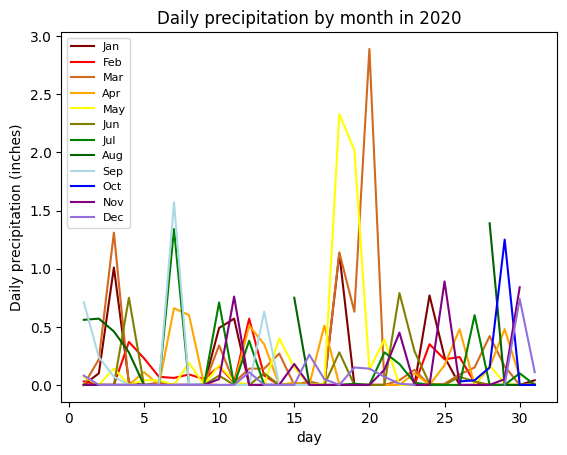

In [10]:
merged_df['Precipitation'] = merged_df['Precipitation'].replace('T', 0.00001)

'''
In this dataset, precipitation that was less than 0.005 inches in marked as T for trace amounts of precipitation. Since this analysis
is looking at severe precipitaion causing flooding, trace values are converted to 0.00001 since they wouldn't have enough of an impact on
the gauge or discharge of the creek to cause flooding.
see article: https://stateclimate.org/pdfs/journal-articles/2013_Adnan_et_al_2013.pdf
'''

merged_df['Precipitation'] = merged_df['Precipitation'].astype(float)
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Day'] = merged_df['Date'].dt.day
mon_day_df = merged_df.loc[ : , ['Day', 'Month', 'Precipitation']]

mon_day_df = mon_day_df.pivot(index = 'Day', columns = 'Month', values = 'Precipitation')
mon_day_df.plot(color=mon_day_df.columns.map({1:'maroon', 2:'red', 3:'chocolate', 4:'orange', 5:'yellow', 6:'olive', 7:'green', \
                                              8:'darkgreen', 9:'lightblue', 10:'blue', 11: 'purple', 12:'mediumpurple'}), xlabel = 'day',\
                ylabel = 'Daily precipitation (inches)', title = 'Daily precipitation by month in 2020')
plt.legend(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize = 8)

## Analysis

Our plot confirms that March 20th stands out with an significantly high level of rainfall for the year. While rainfall levels for other days remain consistently low and visually clustered together, March 20th shows a distinct peak.

Although this supports our thesis to some extent, we aim to examine the correlation between precipitation, gage height, and discharge more closely. To do this, we will create a line plot showing daily precipitation, discharge, and gage levels throughout March.

Text(0.5, 1.0, 'Discharge and precipitation in March 2020')

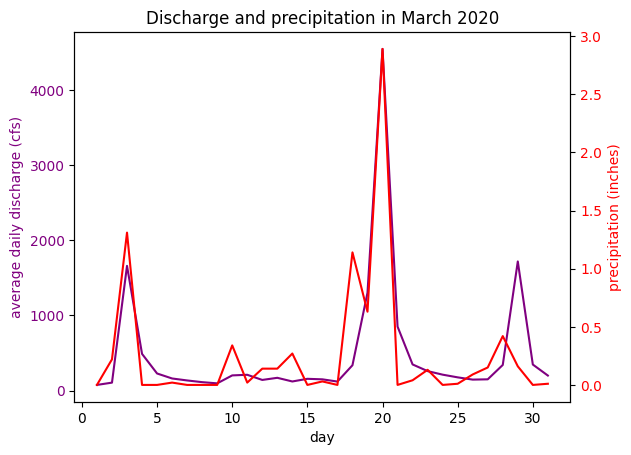

In [13]:
march_df = merged_df[merged_df['Month']==3]
fig, ax1 = plt.subplots()
color='purple'
ax1.set_xlabel('day')
ax1.set_ylabel('average daily discharge (cfs)', color=color)
ax1.plot(march_df['Day'], march_df['Discharge'], color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color='red'
ax2.set_ylabel('precipitation (inches)', color=color)
ax2.plot(march_df['Day'], march_df['Precipitation'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.title('Discharge and precipitation in March 2020')

## Analysis

This graph shows a strong relationship between precipitation and average discharge per day, especially on March 20th, where the big precipitation spike on March 20 lines up almost perfectly with the discharge spike. We theorize that heavy precipitation raises water levels causing high discharge, causing the high flood. Although such a close correlation is not seen in the other days of the month, the two lines generally rise and fall together. 

# Community Impact
The 2020 Granville flood had significant and immediate effects on the local community. Evacuations were ordered, barriers erected, and road closures implemented—including the collapse of a section of Ohio Route 79. Many residents were forced from their homes, and rescuers used boats to carry seniors to safety from flooded apartments. The floodwaters carried away cars, property, and even individuals caught in the surge.

In downtown areas like South Main Street and Ross’ Market, floodwaters rose to knee height, submerging streets, homes, and businesses in muddy water from both rainfall and Raccoon Creek. While the full financial cost of the damage remains uncertain, it is clear that the community faced widespread disruption. Homes and businesses required repairs, roads needed reconstruction, lawns were ruined, appliances damaged, and schools and businesses had to close temporarily, disrupting lives and livelihoods.

Notably, this crisis struck at an especially challenging time—late March 2020—as COVID-19 cases were rapidly increasing across the United States. The combined impact of flood damage and pandemic conditions created a heightened public health risk, with potential implications for community transmission and strain on local resources. In the following section, we examine how these overlapping events may have compounded the effects on public health, particularly through possible mechanisms like wastewater overflow, which can contribute to virus spread in flood-prone areas.

# Covid-19 Impact
A [study ](https://pmc.ncbi.nlm.nih.gov/articles/PMC7510583/) has shown that urban flooding can facilitate the transmission of pathogens, particularly in areas with wastewater overflow or sewage contamination. Floodwaters that mix with untreated sewage may carry harmful bacteria, viruses, and other contaminants, posing significant health risks to affected communities. This is especially relevant considering that COVID-19 has been detected in untreated wastewater, meaning that urban floods, such as the one in Granville, Ohio, could have increased local COVID-19 transmission risks by dispersing contaminated water into streets, homes, and other public areas.

Data from the National Oceanic and Atmospheric Administration (NOAA) describe the specific flood impact levels for Granville. At a flood stage of approximately 16.5 feet, much of the wastewater treatment plant becomes flooded, while at 17 feet, the Granville Wastewater Treatment Plant and nearby Raccoon Valley Park experience significant flooding, leaving the park completely submerged. While no direct reports confirmed flooding at the Granville Wastewater Treatment Plant, news from the Newark Advocate documented severe damage to Raccoon Valley Park. Floodwaters reached equipment storage buildings, exposed a long-abandoned dump site, and scattered glass and metal debris across soccer fields. The article noted that the park suffered its "worst hit in a decade." This severe flooding at Raccoon Valley Park strongly suggests that the wastewater treatment plant may have also been impacted, as both are in the same flood-prone area.

Further corroborating this, data from the U.S. Geological Survey (USGS) recorded flood levels reaching 16.9 feet in Granville around 9:45-10:00 am on March 20, 2020—well within the range associated with critical flooding impacts. Given this information, it is reasonable to infer that the Granville Wastewater Treatment Plant likely experienced flooding, leading to potential environmental and health risks, particularly during the onset of the COVID-19 pandemic.

Given that the Granville Wastewater Treatment Plant likely experienced flooding and COVID-19 is known to be present in untreated sewage, there is reason to consider a possible correlation between the flood and an increase in local COVID-19 cases. Two days after the flood on March 20, 2020, COVID-19 cases in Ohio rose from 169 to 247, a sharp increase of 78 cases (Newark Advocate, 2020). Although Granville-specific COVID-19 data was not reported, Licking County, which includes Granville, recorded a notable rise—from just 1 case on the day of the flood to 7 cases six days later. Although these cases can reasonably result natural from cross-infection within the community, at least one new case was confirmed each day following the flood. Local reports also mentioned that the actual number of cases could be higher, as many residents had difficulty accessing healthcare facilities due to ongoing recovery efforts from the flood.

The dual impact of the flood and the onset of the pandemic added a unique layer of health risk for the community. The timing in late March 2020 aligned with a national surge in COVID-19 cases, leaving residents grappling not only with damage and displacement from flooding but also with the heightened potential for virus exposure. For Central Ohio, this raises significant questions: Did the flooding incident contribute to a spike in local COVID-19 cases? Could contamination from floodwaters have increased transmission risk within the community?

The pandemic also made it more challenging to secure resources for recovery. As residents sought temporary housing, basic supplies, and essential services, the pandemic’s restrictions and shortages made access more difficult. This convergence of flood damage and pandemic conditions may have compounded health risks, straining the capacity of health services and exacerbating the challenges of managing the physical and psychological toll on residents in Central Ohio.

# Conclusion
The 2020 flood in Granville, Ohio, illustrates how environmental disasters intersect with public health crises, creating amplified risks and challenges for affected communities. Through our analysis, we identified the severe flood conditions that likely compromised local wastewater treatment, potentially dispersing untreated sewage and increasing health risks in Central Ohio. This impact was exacerbated by the concurrent COVID-19 pandemic, as cases in Licking County surged shortly after the flood—a concerning correlation given the known presence of COVID-19 in untreated wastewater.

Our findings suggest that this overlap of flooding and pandemic conditions may have deepened the community’s vulnerability, presenting both immediate and lasting repercussions. Beyond physical damage and economic strain, residents likely faced heightened exposure to potential infection sources, limited access to essential resources, and increased difficulty in securing alternative housing. These compounded pressures underscore the importance of robust, integrated disaster-response planning that considers both environmental and health risks.

Ultimately, the Granville flood serves as a case study in how environmental events can exacerbate public health crises, especially in densely populated areas with shared infrastructure. Addressing such challenges requires an understanding of the intricate relationships between environmental, infrastructural, and health-related factors—an approach that is essential to protect communities facing future crises of similar complexity.

### Works Cited
Flood Coalition, Jared Melville (Program Analyst), with Lindsey Holman (Emergency Management Specialist), "*Spring flooding and COVID-19 collide in the Midwest*" (2020)   
https://floodcoalition.org/2020/04/spring-flooding-and-covid-19-collide-in-the-midwest-challenges-and-considerations-for-local-governments/

Newark Advocate, Michaela Sumner, "*Heath condo residents seek cause of flooding, solution to future flooding*" (May 27, 2020)
https://www.newarkadvocate.com/story/news/2020/05/27/heath-condo-residents-seek-solution-future-flooding/5185231002/

Newwark Advocate, Craig McDonald, "*Raccoon Valley Park ravaged by recent storms that swept through Granville*" (April 1, 2020)
https://www.newarkadvocate.com/story/news/local/granville/2020/04/01/raccoon-valley-park-granville-ravaged-recent-storms/5087066002/

Newark Advocate, Beth Burger, "*Ohio’s confirmed coronavirus cases jump by 78 in one day, deaths go from 1 to 3*" (March 21, 2020)
https://www.newarkadvocate.com/story/news/local/2020/03/21/ohios-confirmed-coronavirus-cases-jump-78-deaths-go-1-3/2892184001/

Newark Advocate, Kent Mallet, "*Licking health department reports two more coronavirus cases for 7 total in county*" (March 26, 2020)
https://www.newarkadvocate.com/story/news/2020/03/26/coronavirus-ohio-licking-health-reports-2-more-cases-7-total/2919418001/

Newark Advocate, Michaela Sumner, "*Coronavirus: Licking County cases up to 78; 17 have recovered*" (April 9, 2020)
https://www.newarkadvocate.com/story/news/2020/04/09/coronavirus-licking-county-78-cases-17-recovered/5122033002/

National Library of Medicine, Jie Han , Shanshan He (Both in Department of Environmental Science and Engineering, at Xi'an Jiaotong University) , "*Urban flooding events pose risks of virus spread during the novel coronavirus (COVID-19) pandemic*" (2020)   
https://pmc.ncbi.nlm.nih.gov/articles/PMC7510583/

National Oceanic and Atmospheric Administration, **NOAA** , *National Water Prediction Service*    
https://water.noaa.gov/gauges/grno1

United States Geological Survey, **USGS**    
https://waterdata.usgs.gov/monitoring-location/03145483/#parameterCode=00065&showMedian=false&startDT=2020-01-01&endDT=2020-04-01
